<a href="https://www.kaggle.com/code/janmartins/dv-energy-consumption-r-46?scriptVersionId=224857708" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Carregando bibliotecas e o caminho para o dataset

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/energy-consumption-prediction/Energy_consumption_dataset.csv


In [2]:
path = '/kaggle/input/energy-consumption-prediction/Energy_consumption_dataset.csv'
df_path = pd.read_csv(path)
df_path.head()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732


In [3]:
# Informações em geral sobre os dados

df_path.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              5000 non-null   int64  
 1   Hour               5000 non-null   int64  
 2   DayOfWeek          5000 non-null   object 
 3   Holiday            5000 non-null   object 
 4   Temperature        5000 non-null   float64
 5   Humidity           5000 non-null   float64
 6   SquareFootage      5000 non-null   float64
 7   Occupancy          5000 non-null   int64  
 8   HVACUsage          5000 non-null   object 
 9   LightingUsage      5000 non-null   object 
 10  RenewableEnergy    5000 non-null   float64
 11  EnergyConsumption  5000 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 468.9+ KB


In [4]:
# Verificando se existe algum valor nulo

df_path.isnull().sum()

Month                0
Hour                 0
DayOfWeek            0
Holiday              0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
EnergyConsumption    0
dtype: int64

In [5]:
# Verificando se existe algum valor duplicado

df_path.duplicated().any()

False

# **Consumo Mensal:**

In [6]:
# Agrupando os dados por mês e somando o consumo de energia
consumo_mensal = df_path.groupby('Month')['EnergyConsumption'].sum()

# Ordenando os meses pelo maior consumo de energia
consumo_mensal_sorted = consumo_mensal.sort_values(ascending=False)

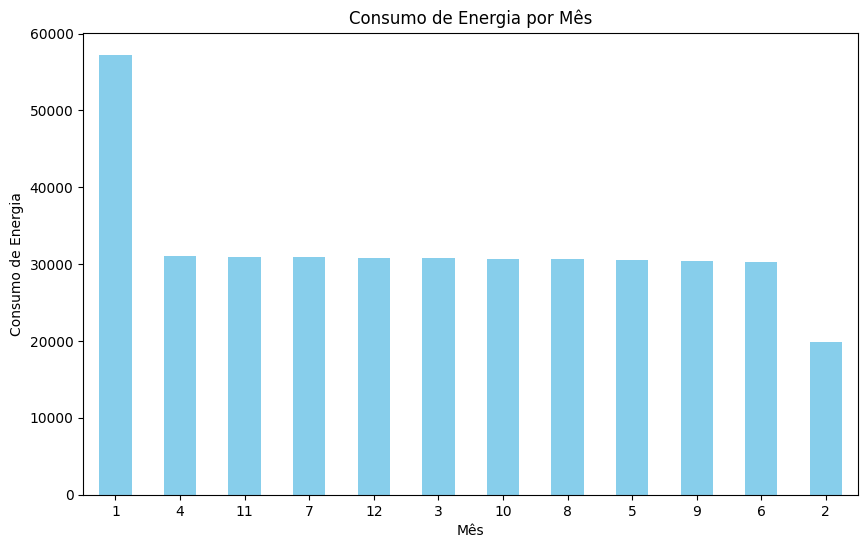

In [7]:
# Gráfico de barras do consumo de energia por mês
plt.figure(figsize=(10, 6))
consumo_mensal_sorted.plot(kind='bar', color='skyblue')
plt.title('Consumo de Energia por Mês')
plt.xlabel('Mês')
plt.ylabel('Consumo de Energia')
plt.xticks(rotation=0)
plt.show()

In [8]:
# Exibindo os resultados
print(consumo_mensal_sorted)

Month
1     57247.160730
4     31034.394942
11    30936.782574
7     30900.515678
12    30851.173956
3     30796.374996
10    30671.422452
8     30624.322678
5     30480.904171
9     30359.124472
6     30263.705685
2     19808.712138
Name: EnergyConsumption, dtype: float64


# **Consumo por hora:**

In [9]:
consumo_hora = df_path.groupby('Hour')['EnergyConsumption'].sum()

consumo_hora_sorted = consumo_hora.sort_values(ascending=False)

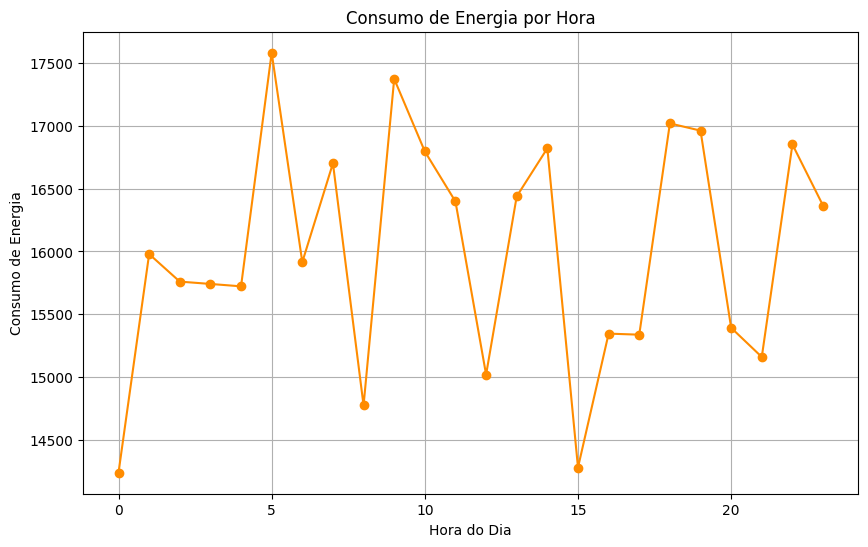

In [10]:
plt.figure(figsize=(10, 6))
consumo_hora.plot(kind='line', color='darkorange', marker='o')
plt.title('Consumo de Energia por Hora')
plt.xlabel('Hora do Dia')
plt.ylabel('Consumo de Energia')
plt.grid(True)
plt.show()

In [11]:
print(consumo_hora_sorted)

Hour
5     17581.307348
9     17373.110861
18    17018.738407
19    16961.549540
22    16851.534131
14    16820.973382
10    16795.930852
7     16701.408910
13    16438.340356
11    16397.511686
23    16364.749977
1     15979.137248
6     15915.127438
2     15760.047428
3     15741.471127
4     15722.390855
20    15392.390587
16    15346.089962
17    15337.726504
21    15160.365711
12    15019.876881
8     14774.845342
15    14280.667146
0     14239.302793
Name: EnergyConsumption, dtype: float64


# **Consumo por temperatura**

In [12]:
consumo_por_temperatura = df_path.groupby('Temperature')['EnergyConsumption'].sum()

consumo_por_temperatura_sorted = consumo_por_temperatura.sort_values(ascending=False)

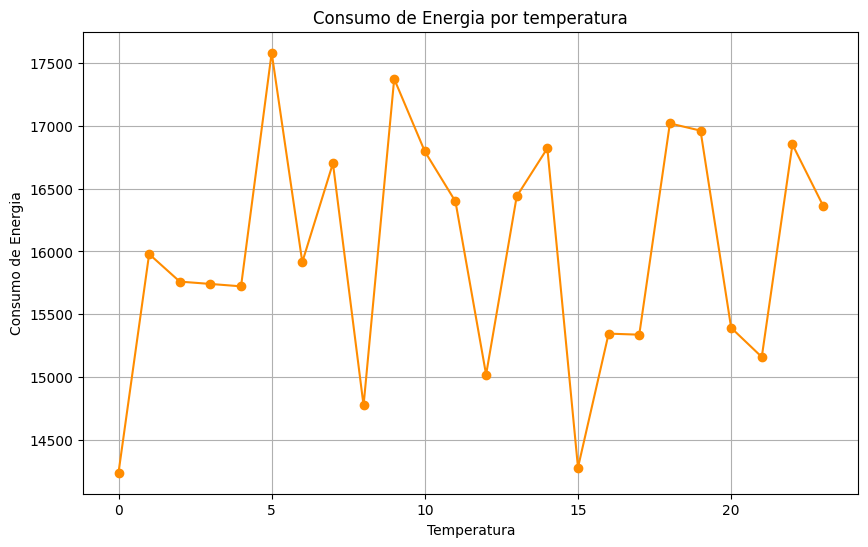

In [13]:
plt.figure(figsize=(10, 6))
consumo_hora.plot(kind='line', color='darkorange', marker='o')
plt.title('Consumo de Energia por temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Consumo de Energia')
plt.grid(True)
plt.show()

In [14]:
print(consumo_por_temperatura_sorted)

Temperature
29.998671    25957.429276
20.007565    19562.894501
25.710427       99.201120
28.498607       99.201120
24.818577       99.201120
                 ...     
25.019816       53.263278
20.461534       53.263278
21.956918       53.263278
21.400221       53.263278
20.880428       53.263278
Name: EnergyConsumption, Length: 4409, dtype: float64


# **Consumo de energia por dia da semana:**

In [15]:
consumo_por_dia_da_semana = df_path.groupby('DayOfWeek')['EnergyConsumption'].sum()

consumo_por_dia_da_semana_sorted = consumo_por_dia_da_semana.sort_values(ascending=False)

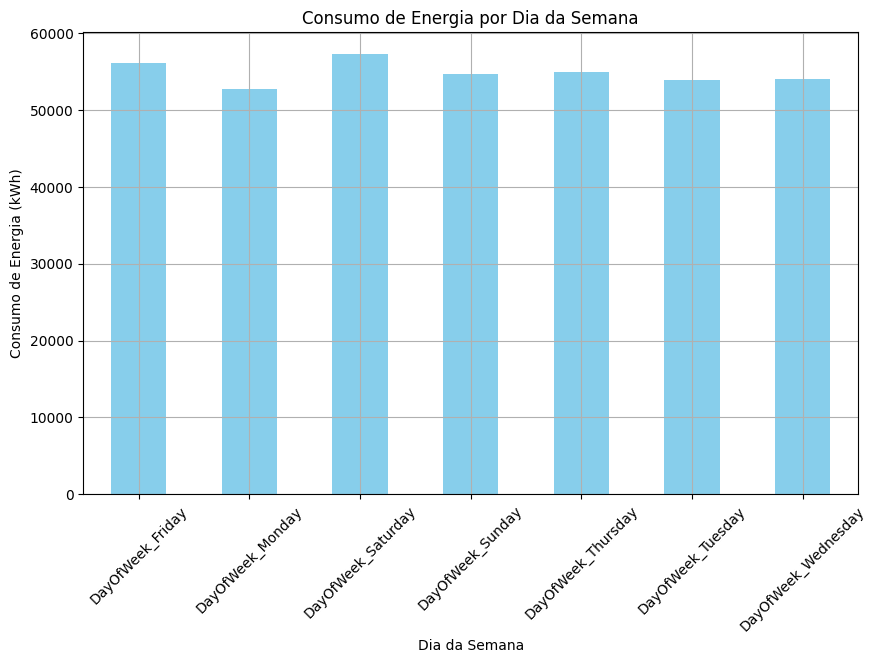

In [16]:
df_path = pd.get_dummies(df_path, columns=['DayOfWeek'], prefix='DayOfWeek')

df_path['DayOfWeek'] = df_path[['DayOfWeek_Monday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday',
                                 'DayOfWeek_Thursday', 'DayOfWeek_Friday', 'DayOfWeek_Saturday', 
                                 'DayOfWeek_Sunday']].idxmax(axis=1)

# Agrupando o consumo de energia por dia da semana
consumo_por_dia = df_path.groupby('DayOfWeek')['EnergyConsumption'].sum()

# Plotando o gráfico
plt.figure(figsize=(10, 6))
consumo_por_dia.plot(kind='bar', color='skyblue')
plt.title('Consumo de Energia por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Consumo de Energia (kWh)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [17]:
print(consumo_por_dia_da_semana_sorted)

DayOfWeek
Saturday     57298.255635
Friday       56208.495623
Thursday     54970.573480
Sunday       54753.511082
Wednesday    54062.552595
Tuesday      53970.267153
Monday       52710.938905
Name: EnergyConsumption, dtype: float64


# Boxplots para visualizar outliers

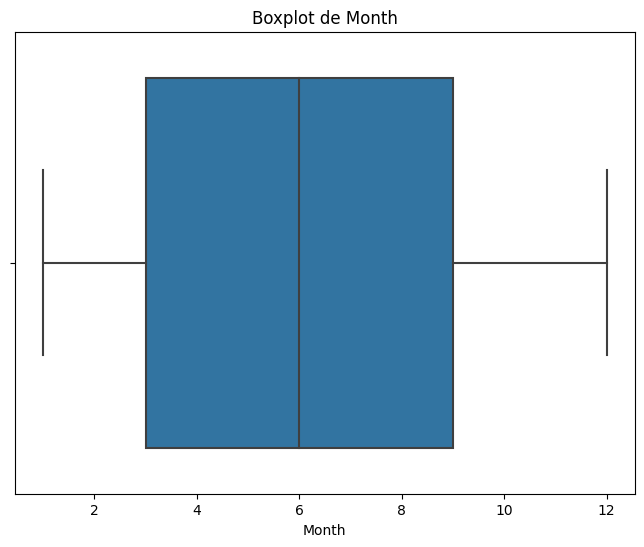

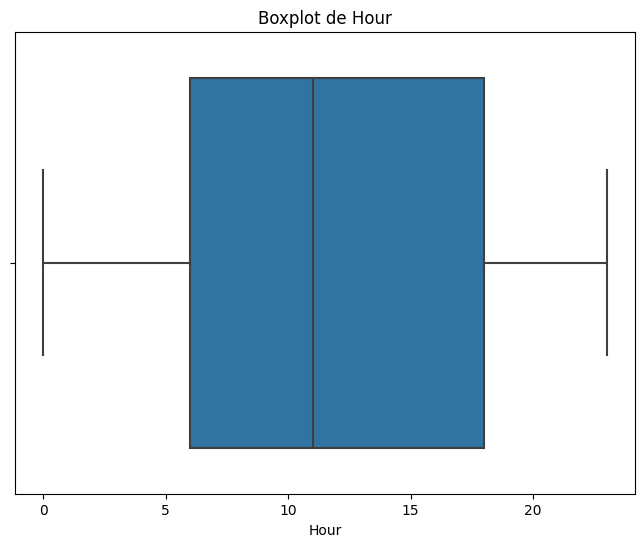

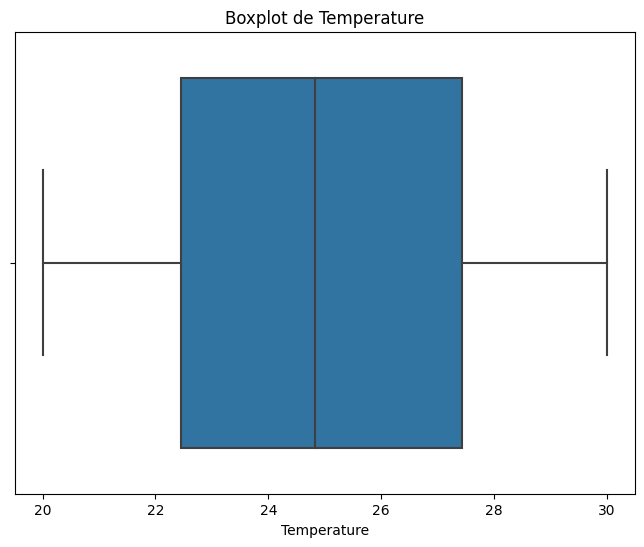

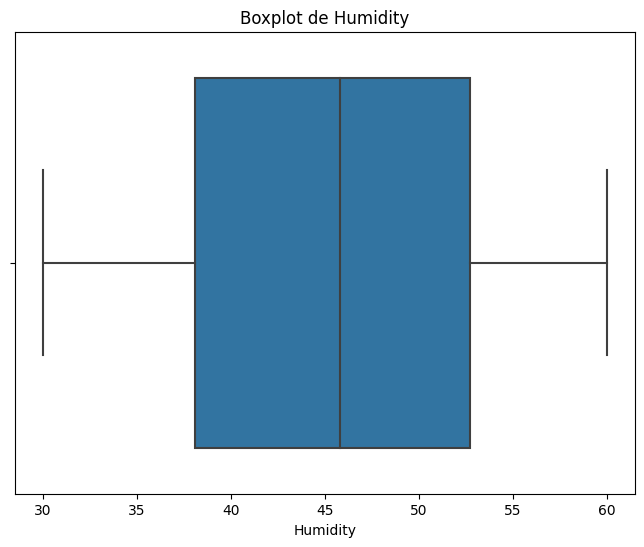

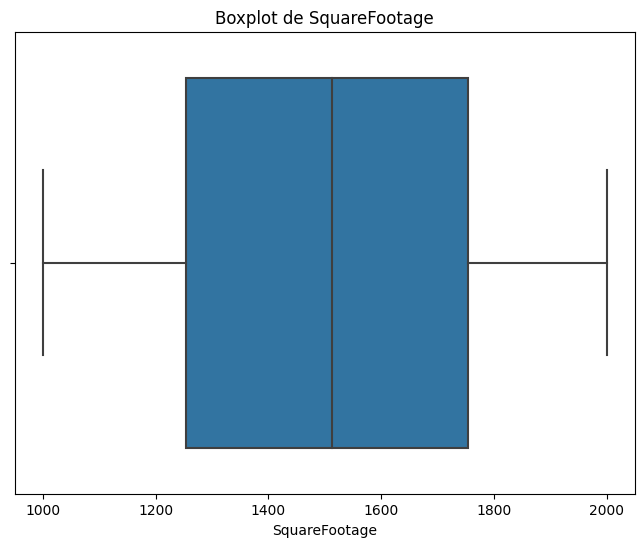

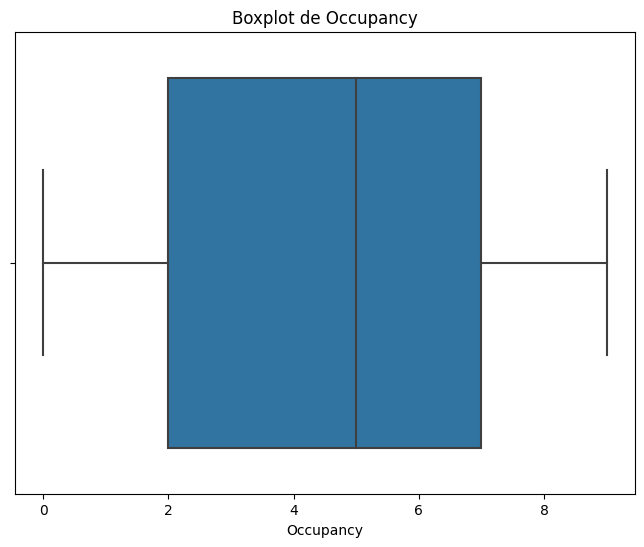

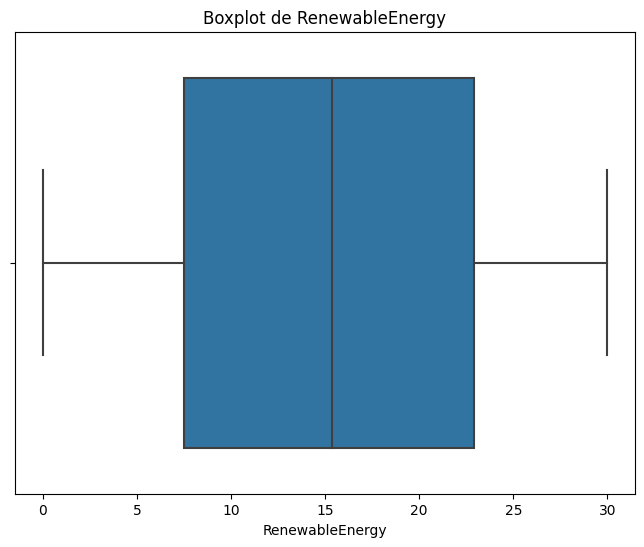

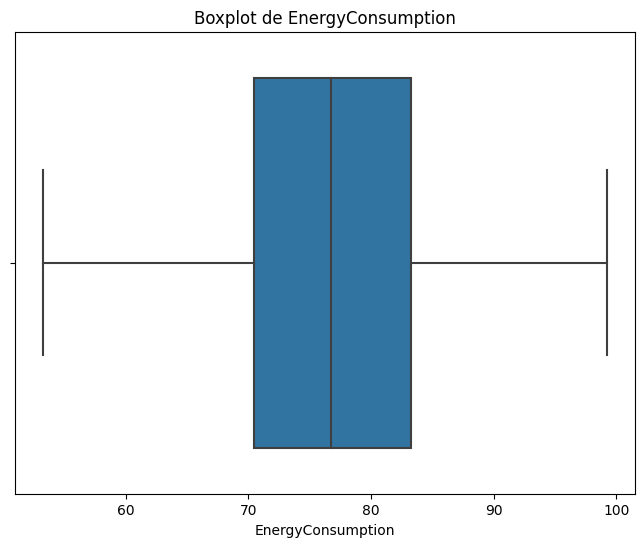

In [18]:
# Visualizar outliers

# Excluindo colunas categóricas e garantindo que estamos tratando apenas numéricas
numerical_columns = df_path.select_dtypes(include=['float64', 'int64']).columns

# Visualizar boxplots para cada coluna numérica
for col in numerical_columns:
    plt.figure(figsize=(8, 6))  # Ajuste o tamanho do gráfico, se necessário
    sns.boxplot(x=df_path[col])
    plt.title(f'Boxplot de {col}')  # Título indicando qual coluna está sendo visualizada
    plt.show()

In [19]:
# One-hot encoding para variáveis categóricas
df_encoded = pd.get_dummies(df_path, columns=['DayOfWeek', 'Holiday', 'HVACUsage', 'LightingUsage'], drop_first=True)

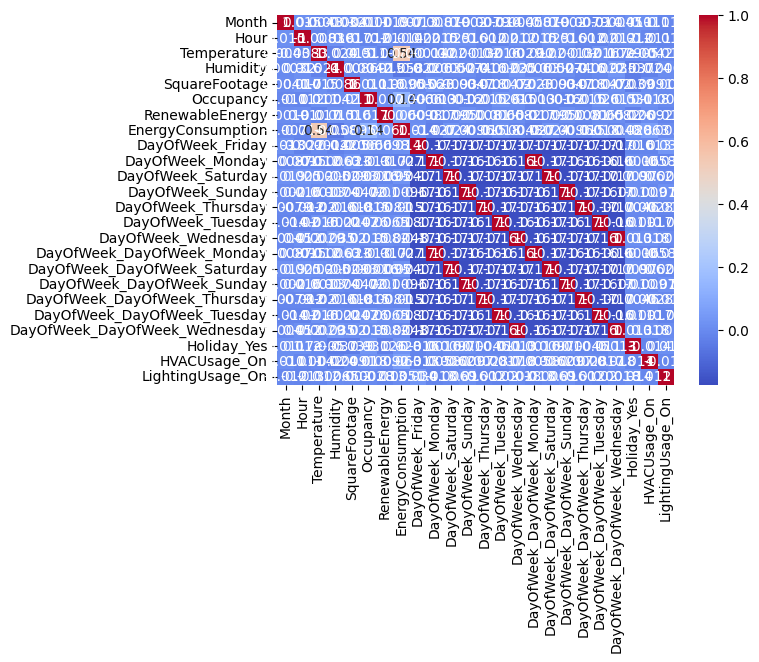

In [20]:
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

# ML

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
# Separar as variáveis independentes (features) e a variável dependente (target)

X = df_encoded.drop(columns=["EnergyConsumption"])  # X com as variáveis independentes
y = df_encoded["EnergyConsumption"]  # y com a variável dependente

# Usando LabelEncoder para colunas categóricas
"""
labelencoder = LabelEncoder()
for coluna in df_path.columns:
    if df_path[coluna].dtype == 'object':  # Para colunas de texto
        df_path[coluna] = labelencoder.fit_transform(df_path[coluna])  # Aplicando LabelEncoder"""

"\nlabelencoder = LabelEncoder()\nfor coluna in df_path.columns:\n    if df_path[coluna].dtype == 'object':  # Para colunas de texto\n        df_path[coluna] = labelencoder.fit_transform(df_path[coluna])  # Aplicando LabelEncoder"

In [23]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escolher e treinar um modelo
model = RandomForestRegressor(random_state=42)

# Treinamento
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# RandomForestRegressor

In [24]:
# Avaliação do modelo
y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

# R²
r2 = r2_score(y_test, y_pred)
print(f'R²: {r2:.2f}')

# Ajuste de Hiperparâmetros (se necessário)
# Exemplo de GridSearchCV para otimizar os parâmetros do modelo
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Melhor combinação de parâmetros
print("Melhores parâmetros:", grid_search.best_params_)

RMSE: 7.97
MAE: 6.33
R²: 0.24
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhores parâmetros: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


O RMSE de 7.97 significa que, em média, a diferença entre as previsões do modelo e os valores reais é de 7.97 unidades.

O MAE de 6.33 indica que, em média, a diferença absoluta entre os valores reais e as previsões do modelo é de 6.33 unidades.

O R² de 0.24 sugere que o modelo explica apenas 24% da variabilidade dos dados. 

In [25]:
# Criando o modelo RandomForest com os melhores parâmetros
rf_model = RandomForestRegressor(
    max_depth=5,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)

# Treinando o modelo
rf_model.fit(X_train, y_train)

# Fazendo as previsões
y_pred = rf_model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

# R²
r2 = r2_score(y_test, y_pred)
print(f'R²: {r2:.2f}')

RMSE: 7.84
MAE: 6.22
R²: 0.26


# GradientBoostingRegressor

In [26]:
# Definir o modelo
model_gb = GradientBoostingRegressor(random_state=42)

# Definir os parâmetros para testar
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search_gb = GridSearchCV(estimator=model_gb, param_grid=param_grid_gb, cv=5, n_jobs=-1, verbose=2)
grid_search_gb.fit(X_train, y_train)

# Melhor combinação de parâmetros
print(f"Melhores parâmetros: {grid_search_gb.best_params_}")

# Avaliar o desempenho do melhor modelo
y_pred_gb = grid_search_gb.best_estimator_.predict(X_test)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}


In [27]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
)

# Treinamento
model_gb.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_gb = model_gb.predict(X_test)

# Avaliar as métricas
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f'Gradient Boosting - RMSE: {rmse_gb:.2f}, MAE: {mae_gb:.2f}, R²: {r2_gb:.2f}')

Gradient Boosting - RMSE: 7.82, MAE: 6.16, R²: 0.27


# xgb

In [28]:
# Definir o modelo
model_xgb = xgb.XGBRegressor(random_state=42)

# Definir os parâmetros para testar
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearchCV
grid_search_xgb = GridSearchCV(estimator=model_xgb, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train, y_train)

# Melhor combinação de parâmetros
print(f"Melhores parâmetros: {grid_search_xgb.best_params_}")

# Avaliar o desempenho do melhor modelo
y_pred_xgb = grid_search_xgb.best_estimator_.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [29]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.8,
)

# Treinamento
model_xgb.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_xgb = model_xgb.predict(X_test)

# Avaliar as métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGBoost - RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, R²: {r2_xgb:.2f}')

XGBoost - RMSE: 8.58, MAE: 6.70, R²: 0.12


# Regressão Linear

In [30]:
# Normalização dos dados
scaler = StandardScaler()

# Normalizando todas as colunas numéricas:
numeric_cols = df_path.select_dtypes(include=['int64', 'float64']).columns
df_path[numeric_cols] = scaler.fit_transform(df_path[numeric_cols])

In [31]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Definir os modelos
model_ridge = Ridge()
model_lasso = Lasso()

# Parâmetros para testar
param_grid_ridge = {
    'alpha': [0.1, 1, 10, 100]
}

param_grid_lasso = {
    'alpha': [0.1, 1, 10, 100]
}

# GridSearchCV para Ridge
grid_search_ridge = GridSearchCV(estimator=model_ridge, param_grid=param_grid_ridge, cv=5, n_jobs=-1, verbose=2)
grid_search_ridge.fit(X_train, y_train)

# GridSearchCV para Lasso
grid_search_lasso = GridSearchCV(estimator=model_lasso, param_grid=param_grid_lasso, cv=5, n_jobs=-1, verbose=2)
grid_search_lasso.fit(X_train, y_train)

# Melhor combinação de parâmetros
print(f"Melhores parâmetros (Ridge): {grid_search_ridge.best_params_}")
print(f"Melhores parâmetros (Lasso): {grid_search_lasso.best_params_}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Melhores parâmetros (Ridge): {'alpha': 100}
Melhores parâmetros (Lasso): {'alpha': 0.1}


In [33]:
# Ajustando o modelo Ridge com alpha = 100
ridge_model = Ridge(alpha=100)
ridge_model.fit(X_train, y_train)
ridge_score = ridge_model.score(X_test, y_test)

# Ajustando o modelo Lasso com alpha = 0.1
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_score = lasso_model.score(X_test, y_test)

# Mostrando as pontuações dos modelos
print(f"Pontuação do Ridge (R²): {ridge_score}")
print(f"Pontuação do Lasso (R²): {lasso_score}")

Pontuação do Ridge (R²): 0.2702058961929217
Pontuação do Lasso (R²): 0.27256162381066495


# Redes Neurais

In [34]:
from sklearn.neural_network import MLPRegressor

In [35]:
# Normalizar os dados de entrada (X) para que fiquem com média 0 e desvio padrão 1
X_scaled = scaler.fit_transform(X)

# Definir o modelo de rede neural (MLP - Multi-layer Perceptron)
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

In [36]:
# Definir parâmetros para o ajuste fino
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (200,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'learning_rate': ['constant', 'adaptive']
}

# Definir o modelo de rede neural
mlp_model = MLPRegressor(max_iter=1000, random_state=42)

# Realizar a busca de hiperparâmetros
grid_search = GridSearchCV(mlp_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_scaled, y)

# Melhor modelo e parâmetros
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
best_mlp_model = grid_search.best_estimator_

# Avaliar o modelo otimizado
best_pred = best_mlp_model.predict(X_scaled)
best_r2 = best_mlp_model.score(X_scaled, y)
best_rmse = np.sqrt(mean_squared_error(y, best_pred))

print(f"Rede Neural Otimizada - R²: {best_r2:.3f}, RMSE: {best_rmse:.3f}")


Melhores parâmetros encontrados: {'activation': 'relu', 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'adam'}
Rede Neural Otimizada - R²: 0.367, RMSE: 7.345


In [37]:
xgb_model = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    learning_rate='constant'
)

# Treinar o modelo
mlp_model.fit(X_scaled, y)

# Fazer previsões com o modelo treinado
y_pred = mlp_model.predict(X_scaled)

# Avaliar o modelo usando R² e RMSE
r2 = mlp_model.score(X_scaled, y)  # R²
rmse = np.sqrt(mean_squared_error(y, y_pred))  # RMSE

print(f"Rede Neural (MLP) - R²: {r2:.3f}, RMSE: {rmse:.3f}")

Rede Neural (MLP) - R²: 0.464, RMSE: 6.759


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
